#Individual Assignment 1


## Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

### Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# filter dplyr warnings
import warnings
warnings.filterwarnings("ignore")

# Setup the libraries needed for data handling, plotting, modeling, and evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix
from IPython.display import display

In [2]:
# Load the COMPAS dataset from GitHub into a pandas DataFrame
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
raw_data.shape[0]

7214

In [3]:
# Display the first 10 rows of the raw dataset
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
# Clean the dataset, apply the assignment filters, and create the categorical variables used in the analysis

numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[["age", "c_charge_degree", "race", "age_cat", "score_text", "sex","priors_count", "days_b_screening_arrest", "decile_score","is_recid", "two_year_recid", "c_jail_in", "c_jail_out"]].copy()

# Filtering
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"].copy()

# Datetime conversion
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")

# Derived factor-style variables
df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = pd.Categorical(df["age_cat"],categories=["Less than 25", "25 - 45", "Greater than 45"])
df["race_factor"] = pd.Categorical(df["race"], categories=["African-American", "Asian", "Caucasian", "Hispanic", "Native American", "Other"])
df["gender_factor"] = pd.Categorical(df["sex"],categories=["Female", "Male"])
df["score_factor"] = pd.Categorical(np.where(df["score_text"] != "Low", "HighScore", "LowScore"),categories=["LowScore", "HighScore"])

# Numeric target for logistic regression
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

df.shape[0]

6172

In [5]:
# Display the first 10 rows of the clean dataset
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor,score_binary
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore,0
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore,0
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore,0
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore,0
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore,1


In [6]:
# Show the structure and data types of the clean dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   object             
 2   race                     6172 non-null   object             
 3   age_cat                  6172 non-null   object             
 4   score_text               6172 non-null   object             
 5   sex                      6172 non-null   object             
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   int64              
 10  two_year_recid           6172 non-null   int64              
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
# Compute length of stay and its correlation with decile score
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.20747808478031807)

After filtering we have the following demographic breakdown:

In [8]:
# Summarize the age categories
df["age_cat"].value_counts(dropna=False)

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [9]:
# Summarize the race categories
df["race"].value_counts(dropna=False)

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
# Print the percentage of defendants in each main race group
race_pct = df["race"].value_counts(normalize=True).mul(100)

print("Black defendants: %.2f%%" % race_pct.get("African-American", 0))
print("White defendants: %.2f%%" % race_pct.get("Caucasian", 0))
print("Hispanic defendants: %.2f%%" % race_pct.get("Hispanic", 0))
print("Asian defendants: %.2f%%" % race_pct.get("Asian", 0))
print("Native American defendants: %.2f%%" % race_pct.get("Native American", 0))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
# Summarize the COMPAS score labels
df["score_text"].value_counts(dropna=False)

,count
score_text,
Low,3421
Medium,1607
High,1144


In [12]:
# Create a cross-tabulation of sex by race
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
# Summarize the sex variable
df["sex"].value_counts(dropna=False)

,count
sex,
Male,4997
Female,1175


In [14]:
# Print the percentage of men and women in the dataset
sex_pct = df["sex"].value_counts(normalize=True).mul(100)

print("Men: %.2f%%" % sex_pct.get("Male", 0))
print("Women: %.2f%%" % sex_pct.get("Female", 0))

Men: 80.96%
Women: 19.04%


In [15]:
# Count how many defendants recidivated within two years
(df["two_year_recid"] == 1).sum()

np.int64(2809)

In [16]:
# Compute the percentage of defendants who recidivated within two years
(df["two_year_recid"] == 1).mean() * 100

np.float64(45.51198963058976)

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

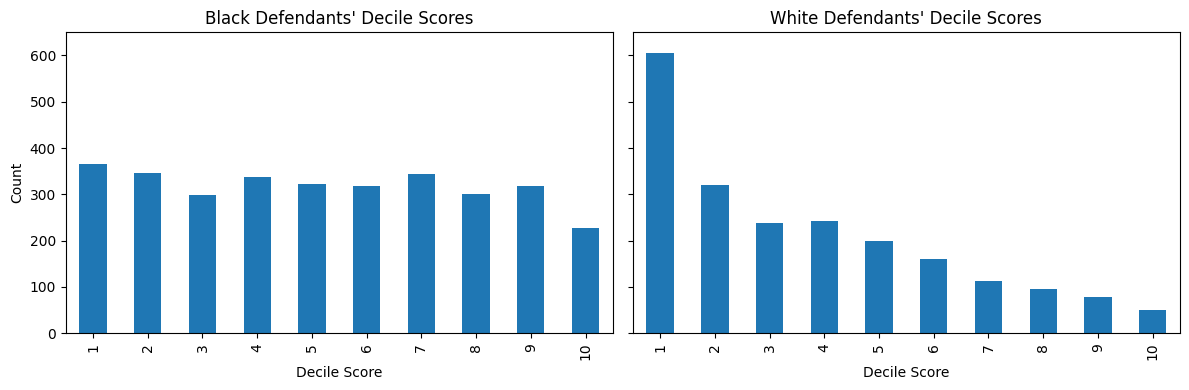

In [17]:
# Plot the decile score distributions for Black and White defendants
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

black_counts = df.loc[df["race"] == "African-American", "decile_score"].value_counts().sort_index()
white_counts = df.loc[df["race"] == "Caucasian", "decile_score"].value_counts().sort_index()

black_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Black Defendants' Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

white_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("White Defendants' Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [18]:
# Create a cross-tabulation of decile score by race
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [19]:
# Fit the logistic regression model
model_glm = smf.logit("score_binary ~ C(gender_factor, Treatment(reference='Male')) + C(age_factor, Treatment(reference='25 - 45')) + C(race_factor, Treatment(reference='Caucasian')) + priors_count + C(crime_factor) + two_year_recid", data=df).fit()
print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        14:36:59   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------

### Interpretation of the Logistic Regression

This logistic regression tests whether race remains associated with receiving a higher COMPAS score after controlling for gender, age category, priors count, charge degree, and two-year recidivism. In the lecture workflow, this step is used as a statistical framing tool to compare coefficients and predicted probabilities while controlling for relevant covariates.

The key idea is that if the coefficient for `race_factor[T.African-American]` is positive, then Black defendants are associated with higher odds of receiving a high-risk classification relative to the Caucasian reference group, holding the other variables constant. Minor numerical differences from the R output may occur because Python and R can differ slightly in factor handling and estimation details, but the interpretation remains conceptually the same.

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [20]:
# Compute the adjusted Black-versus-White effect from the fitted model
control = np.exp(model_glm.params["Intercept"]) / (1 + np.exp(model_glm.params["Intercept"]))
beta_black = model_glm.params["C(race_factor, Treatment(reference='Caucasian'))[T.African-American]"]
np.exp(beta_black) / (1 - control + (control * np.exp(beta_black)))

np.float64(1.452837413382345)

Women are 19.4% more likely than men to get a higher score.

In [21]:
# Compute the adjusted Female-versus-Male effect from the fitted model
beta_female = model_glm.params["C(gender_factor, Treatment(reference='Male'))[T.Female]"]
np.exp(beta_female) / (1 - control + (control * np.exp(beta_female)))

np.float64(1.1947946538834509)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [22]:
# Compute the adjusted Under-25 effect relative to the 25-45 group
beta_under25 = model_glm.params["C(age_factor, Treatment(reference='25 - 45'))[T.Less than 25]"]
np.exp(beta_under25) / (1 - control + (control * np.exp(beta_under25)))

np.float64(2.496119530753956)

In [23]:
# Generate predicted probabilities and predicted classes
df["pred_prob"] = model_glm.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")

In [24]:
# Build the overall confusion matrix and compute the main classification metrics
print("Overall Confusion Matrix")
overall_cm = pd.crosstab(pd.Series(df["pred_class"], name="Predicted"),pd.Series(df["two_year_recid"], name="Actual"))
display(overall_cm)

TP = overall_cm.loc["Recid", 1] if ("Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
TN = overall_cm.loc["No Recid", 0] if ("No Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FP = overall_cm.loc["Recid", 0] if ("Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FN = overall_cm.loc["No Recid", 1] if ("No Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
n = overall_cm.to_numpy().sum()

print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")

Overall Confusion Matrix


Actual,0,1
Predicted,,
No Recid,2653,945
Recid,710,1864



Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [25]:
# Compute confusion matrix metrics separately for each race group
print("Confusion Matrix by Race")

temp = df.copy()
temp["actual"] = temp["two_year_recid"].astype(int)
temp["pred"] = (temp["pred_class"] == "Recid").astype(int)

race_metrics = (
    temp.groupby("race")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum()
    }))
    .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False)

display(race_metrics)

Confusion Matrix by Race


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR
0,African-American,3175,1373,959,555,288,0.734,0.712,0.827,0.367,0.173
2,Caucasian,2103,381,1148,133,441,0.727,0.741,0.464,0.104,0.536
3,Hispanic,509,81,306,14,108,0.760,0.853,0.429,0.044,0.571
5,Other,343,22,216,3,102,0.694,0.880,0.177,0.014,0.823
1,Asian,31,2,22,1,6,0.774,0.667,0.250,0.043,0.750
4,Native American,11,5,2,4,0,0.636,0.556,1.000,0.667,0.000


In [26]:
# Compute the FPR and FNR disparity of each race relative to Caucasians
print("FPR and FNR Disparity by Race")

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

white_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].iloc[0]
white_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].iloc[0]

disparity["delta_FPR"] = (disparity["FPR"] - white_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - white_fnr).round(3)

display(disparity)

FPR and FNR Disparity by Race


,race,n,FPR,FNR,delta_FPR,delta_FNR
0,African-American,3175,0.367,0.173,0.263,-0.363
2,Caucasian,2103,0.104,0.536,0.000,0.000
3,Hispanic,509,0.044,0.571,-0.060,0.035
5,Other,343,0.014,0.823,-0.090,0.287
1,Asian,31,0.043,0.750,-0.061,0.214
4,Native American,11,0.667,0.000,0.563,-0.536


### Interpretation of Group Error-Rate Disparities

This table compares false positive rates (FPR) and false negative rates (FNR) across race groups using Caucasians as the reference category. In the COMPAS lecture workflow, the main fairness lens is whether error rates differ across groups rather than whether the model is simply accurate on average.

A positive `delta_FPR` means that a group experiences more false positives than Caucasians, while a positive `delta_FNR` means that a group experiences more false negatives than Caucasians. These differences are important because they show how a model can produce unequal error burdens across groups even when it appears to perform reasonably well overall.

#Individual Assignment 2

In [27]:
# Run once if needed
%pip install lime
%pip install shap
%pip install dice-ml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=099a0188892372544cf90389a99e512feadc13e4c01fd96e9a35b360558b751b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.7 MB/s eta 0:00:00


In [28]:
# Define features and convert jail dates to numeric values
import numpy as np
import pandas as pd

target = "two_year_recid"

df_explain = df.copy()

for col in ["c_jail_in", "c_jail_out"]:
    dt = pd.to_datetime(df_explain[col], errors="coerce")
    df_explain[f"{col}_num"] = dt.map(lambda x: x.timestamp() if pd.notnull(x) else np.nan)

for col in ["c_jail_in_num", "c_jail_out_num"]:
    df_explain[col] = df_explain[col].fillna(df_explain[col].median())

numeric_features = [
    "age",
    "priors_count",
    "decile_score",
    "days_b_screening_arrest",
    "is_recid",
    "c_jail_in_num",
    "c_jail_out_num",
]

category_features = [
    "age_cat",
    "sex",
    "race",
    "c_charge_degree",
    "score_text",
]

features = numeric_features + category_features

X = df_explain[features].copy()
y = df_explain[target].astype(int)

In [29]:
# Train/test split

# Split the cleaned COMPAS data into training and test sets
from sklearn.model_selection import train_test_split

# X and y from the cleaned COMPAS cohort (Lecture 01)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 12), Test: (1235, 12)


In [30]:
# Fit logistic regression and gradient-boosted tree

#Preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", ohe, category_features),
])

In [31]:
#Logistic regression (GLM -- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'decile_score',
                                                   'days_b_screening_arrest',
                                                   'is_recid', 'c_jail_in_num',
                                                   'c_jail_out_num']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [32]:
# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    )),
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'decile_score',
                                                   'days_b_screening_arrest',
                                                   'is_recid', 'c_jail_in_num',
                                                   'c_jail_out_num']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [33]:
# Compare model performance by race

# Create a function to compare model performance by race
import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix,
                             accuracy_score,
                             roc_auc_score)

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()

        auc = roc_auc_score(gdf["actual"], gdf["pred_prob"]) if gdf["actual"].nunique() > 1 else np.nan

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(
                gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else np.nan,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else np.nan,
            "AUC": round(auc, 3) if pd.notnull(auc) else np.nan,
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR  FNR    AUC
0  African-American  641     0.977  0.049  0.0  0.991
2         Caucasian  427     0.972  0.045  0.0  0.994
3          Hispanic   94     0.968  0.061  0.0  0.974
5             Other   65     0.985  0.021  0.0  1.000
1             Asian    7     1.000  0.000  0.0  1.000
4   Native American    1     1.000  0.000  NaN    NaN

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.973  0.049  0.006  0.992
2         Caucasian  427     0.972  0.045  0.000  0.990
3          Hispanic   94     0.957  0.061  0.022  0.970
5             Other   65     0.985  0.021  0.000  0.999
1             Asian    7     1.000  0.000  0.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN


##Question: 1

Compute SHAP values for your model on the test set. Produce: (a) a beeswarm summary plot, (b) a waterfall plot for the highest-risk and lowest-risk defendant in each racial group.

 97%|=================== | 1203/1235 [00:11<00:00]       

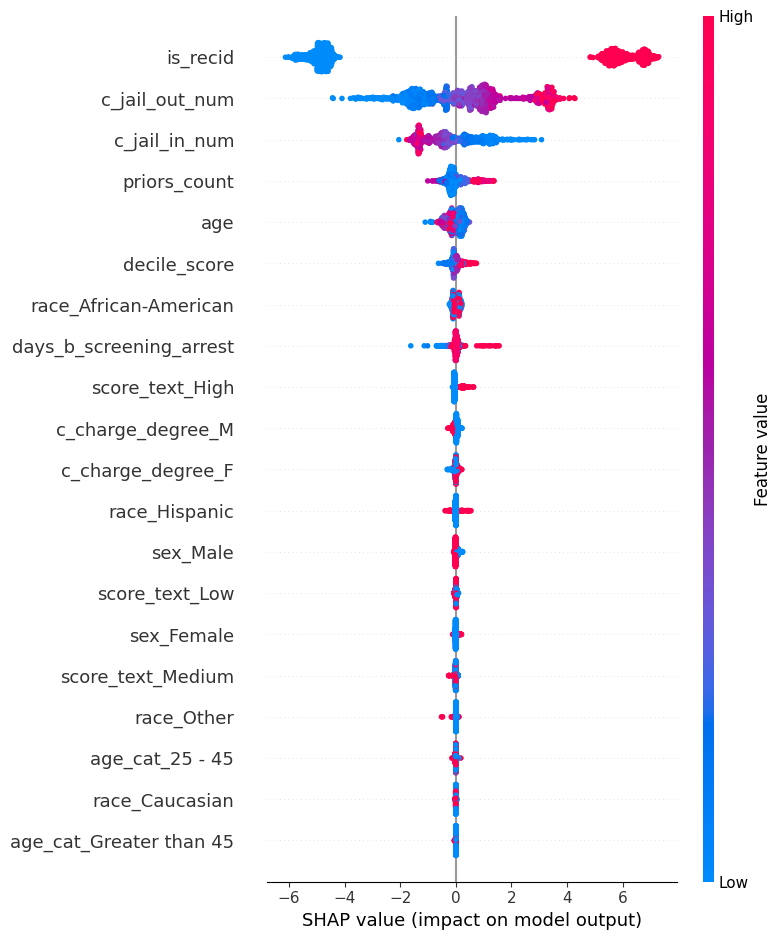

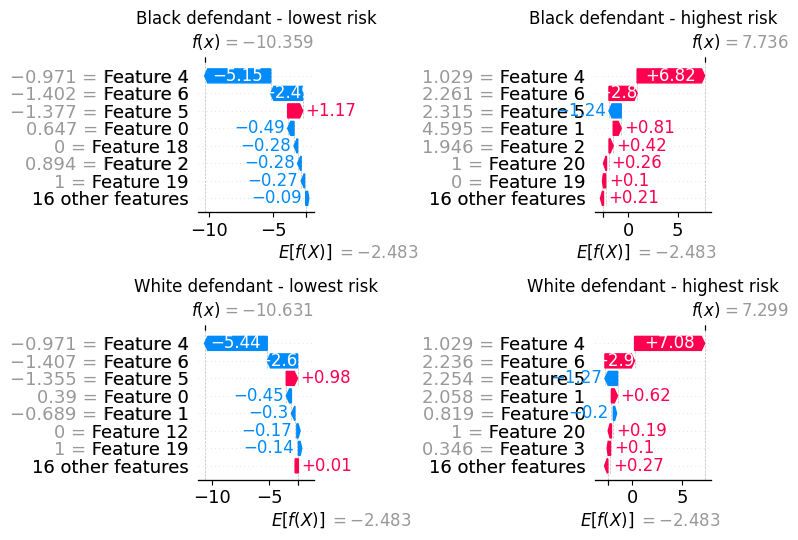

In [38]:
# SHAP beeswarm and waterfall: highest-risk and lowest-risk defendants by racial group

# !pip install shap
import shap
import matplotlib.pyplot as plt

fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]

X_test_enc = fitted_preprocessor.transform(X_test)
if hasattr(X_test_enc, "toarray"):
    X_test_enc = X_test_enc.toarray()

feat_names = (numeric_features +
list(fitted_preprocessor
.named_transformers_["cat"]
.get_feature_names_out(category_features)))

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)

shap_values = explainer_shap(X_test_enc, check_additivity=False)

# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
                  feature_names=feat_names)

# Select highest-risk and lowest-risk defendant in each racial group
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_candidates = X_test_copy[X_test_copy["race"] == "African-American"].sort_values("pred_prob")
white_candidates = X_test_copy[X_test_copy["race"] == "Caucasian"].sort_values("pred_prob")

selected_cases = [
    ("Black defendant - lowest risk", black_candidates.index[0]),
    ("Black defendant - highest risk", black_candidates.index[-1]),
    ("White defendant - lowest risk", white_candidates.index[0]),
    ("White defendant - highest risk", white_candidates.index[-1]),
]

# Waterfall: highest-risk and lowest-risk defendant in each racial group
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (label, idx) in zip(axes.flatten(), selected_cases):
    loc = X_test.index.get_loc(idx)
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc],
                        max_display=8,
                        show=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()

The SHAP results show that the model is driven mainly by is_recid, followed by c_jail_out_num, c_jail_in_num, priors_count, age, and decile_score. In the waterfall plots, low-risk defendants are pushed toward No Recid mostly by is_recid = 0, while high-risk defendants are pushed toward Recid mostly by is_recid = 1. Overall, the model seems to rely more on these risk-related features than on race directly.

## Question 2

Run LIME on the same four individuals. Compare LIME and SHAP feature attributions. Where do they agree? Where do they diverge? What does divergence imply for governance?

In [36]:
# LIME explanations: highest-risk and lowest-risk defendants by racial group

#!pip install lime
from lime.lime_tabular import LimeTabularExplainer

fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
X_train_enc = fitted_preprocessor.transform(X_train)

lime_feature_names = numeric_features + list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)
)

explainer = LimeTabularExplainer(
    training_data=np.asarray(X_train_enc),
    feature_names=lime_feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

# Select the highest-risk and lowest-risk defendants in each racial group
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_candidates = X_test_copy[
    X_test_copy["race"] == "African-American"
].sort_values("pred_prob")

white_candidates = X_test_copy[
    X_test_copy["race"] == "Caucasian"
].sort_values("pred_prob")

black_low_idx = black_candidates.index[0]
black_high_idx = black_candidates.index[-1]
white_low_idx = white_candidates.index[0]
white_high_idx = white_candidates.index[-1]

selected_cases = [
    ("Black defendant - lowest risk", black_low_idx),
    ("Black defendant - highest risk", black_high_idx),
    ("White defendant - lowest risk", white_low_idx),
    ("White defendant - highest risk", white_high_idx),
]

# Generate and print the LIME explanations for the four selected defendants
for label, idx in selected_cases:
    row_enc = np.asarray(fitted_preprocessor.transform(X_test.loc[[idx]]))

    exp = explainer.explain_instance(
        data_row=row_enc[0],
        predict_fn=gbt_pipeline.named_steps["classifier"].predict_proba,
        num_features=6,
    )

    print(f"\nLIME: {label}")
    print(f"Predicted probability: {X_test_prob[X_test.index.get_loc(idx)]:.3f}")

    for feat, weight in exp.as_list():
        print(f"{feat:<45} {weight:+.4f}")


LIME: Black defendant - lowest risk
Predicted probability: 0.000
is_recid <= -0.97                             -0.7460
c_jail_out_num <= -0.89                       -0.2233
c_jail_in_num <= -0.90                        +0.1052
days_b_screening_arrest > 0.15                +0.0810
0.00 < race_African-American <= 1.00          -0.0221
score_text_High <= 0.00                       -0.0199

LIME: Black defendant - highest risk
Predicted probability: 1.000
-0.97 < is_recid <= 1.03                      +0.7308
c_jail_out_num > 0.63                         +0.1722
c_jail_in_num > 0.67                          -0.1420
days_b_screening_arrest <= 0.15               -0.0891
0.00 < race_African-American <= 1.00          -0.0236
sex_Female > 0.00                             +0.0232

LIME: White defendant - lowest risk
Predicted probability: 0.000
is_recid <= -0.97                             -0.7349
c_jail_out_num <= -0.89                       -0.2195
c_jail_in_num <= -0.90                       

LIME and SHAP agree on the main drivers: is_recid is the most important feature, with jail-related variables also contributing a lot. For low-risk cases, both methods push the prediction toward No Recid, and for high-risk cases they push it toward Recid. They differ more on smaller features, so the strongest conclusions should come from the features that both methods identify consistently.

## Question 3
Generate at least one counterfactual per individual using DiCE
(Python) or NICE (R). Report the minimal feature changes required
to flip the prediction. Flag any counterfactuals that require changes
to immutable features (race, sex).

In [37]:
# Counterfactuals with DiCE: highest-risk and lowest-risk defendants by racial group

# !pip install dice-ml
import dice_ml
from dice_ml import Dice

# DiCE requires a pandas DataFrame and a wrapped model
y_train_named = y_train.rename(target)

dice_data = dice_ml.Data(
    dataframe = pd.concat([X_train, y_train_named], axis=1),
    continuous_features = numeric_features,
    outcome_name = target
)

dice_model = dice_ml.Model(
    model = gbt_pipeline,
    backend = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in selected_cases:

    query = X_test.loc[[idx]][features]

    try:
        cf = exp_dice.generate_counterfactuals(
            query,
            total_CFs = 1,
            desired_class = "opposite",
            permitted_range = {"age" : [18, 70],
                               "priors_count": [0, 38]},
            features_to_vary = "all"
        )

        print(f"\n DiCE counterfactuals: {label} ")
        cf.visualize_as_dataframe(show_only_changes=True)
        print("Immutable features race and sex were not allowed to vary.")

    except Exception as e:
        print(f"\n DiCE counterfactuals: {label} ")
        print("No counterfactuals found with the random method for this defendant.")

100%|██████████| 1/1 [00:00<00:00,  5.92it/s]


 DiCE counterfactuals: Black defendant - lowest risk 
Query instance (original outcome : 0)


,age,priors_count,decile_score,days_b_screening_arrest,is_recid,c_jail_in_num,c_jail_out_num,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,42,0,7,0.0,0,1.357114e+09,1.357700e+09,25 - 45,Male,African-American,M,Medium,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,decile_score,days_b_screening_arrest,is_recid,c_jail_in_num,c_jail_out_num,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,-,-,-,-,1,-,-,-,-,-,-,-,1


...


 DiCE counterfactuals: White defendant - highest risk 
Query instance (original outcome : 1)


,age,priors_count,decile_score,days_b_screening_arrest,is_recid,c_jail_in_num,c_jail_out_num,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,44,13,9,0.0,1,1.416660e+09,1.418119e+09,25 - 45,Male,Caucasian,F,High,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,decile_score,days_b_screening_arrest,is_recid,c_jail_in_num,c_jail_out_num,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,39,-,-,-,0,-,-,-,-,-,-,-,0


Immutable features race and sex were not allowed to vary.


DiCE found counterfactuals for all four selected individuals. Most prediction flips were driven mainly by changing is_recid, and in some cases also score_text, c_charge_degree, or age. None of the counterfactuals required changing race or sex, but some changes are not realistically actionable, so the recourse results should be interpreted cautiously.

## Question 4

Write a 300-word governance memo addressed to a hypothetical
court auditor: summarise what your explanations reveal about model
behaviour, any limitations of the methods, and what furthermonitoring you recommend.

##Governance memo

The explanation results suggest that this model is driven primarily by is_recid, followed by jail-date variables, priors count, age, and decile score. SHAP and LIME are consistent on this main pattern across the four audited individuals. In particular, both methods show that the strongest push toward a positive prediction comes from is_recid = 1, while the strongest push toward a negative prediction comes from is_recid = 0. The direct contribution of race appears smaller than the contribution of these core variables, but that does not eliminate the possibility of indirect racial effects through correlated proxies.

The main limitation is that the model appears to rely heavily on variables that may be too close to the outcome being predicted. This is especially concerning because the counterfactual analysis also flips predictions mainly by changing is_recid, and in one case by changing age. Those are not strong examples of meaningful or actionable recourse. In addition, LIME and SHAP agree on the dominant features but differ on lower-level attributions, which means local explanations should be treated as diagnostic approximations rather than definitive accounts of causality.

I recommend four monitoring steps. First, perform a feature-governance audit to verify whether any variables create target leakage or use information that would not be available at decision time. Second, re-estimate the model after removing questionable variables and compare performance and fairness. Third, monitor false positive rates, false negative rates, and calibration by race over time, especially for groups with small sample sizes. Fourth, require multi-method explainability reviews so that decisions are not justified using only one local explainer.